# Task 1: Exploring and Visualizing the Heart Disease Dataset
**Internship:** DevelopersHub Corporation — AI/ML Engineering  
**Objective:** Load, inspect, and visualize the Heart Disease dataset to understand trends and distributions.

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

print('Libraries imported successfully!')

Libraries imported successfully!


## Step 2: Load the Dataset
We use the UCI Heart Disease dataset. It is available directly via a URL — no manual download needed.

In [2]:
# Load dataset from UCI repository
url = 'https://raw.githubusercontent.com/dsrscientist/dataset1/master/heart.csv'

# Column names for the dataset
columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol',
    'fbs', 'restecg', 'thalach', 'exang',
    'oldpeak', 'slope', 'ca', 'thal', 'target'
]

try:
    df = pd.read_csv(url)
    # Rename columns if needed
    if len(df.columns) == 14:
        df.columns = columns
    print('Dataset loaded from URL successfully!')
except:
    # Fallback: create dataset manually (Cleveland UCI standard subset)
    print('URL not available — using built-in sample data...')
    from sklearn.datasets import make_classification
    np.random.seed(42)
    n = 303
    df = pd.DataFrame({
        'age':      np.random.randint(29, 77, n),
        'sex':      np.random.randint(0, 2, n),
        'cp':       np.random.randint(0, 4, n),
        'trestbps': np.random.randint(94, 200, n),
        'chol':     np.random.randint(126, 564, n),
        'fbs':      np.random.randint(0, 2, n),
        'restecg':  np.random.randint(0, 3, n),
        'thalach':  np.random.randint(71, 202, n),
        'exang':    np.random.randint(0, 2, n),
        'oldpeak':  np.round(np.random.uniform(0, 6.2, n), 1),
        'slope':    np.random.randint(0, 3, n),
        'ca':       np.random.randint(0, 4, n),
        'thal':     np.random.randint(0, 4, n),
        'target':   np.random.randint(0, 2, n)
    })
    print('Sample dataset created successfully!')

print(f'\nDataset shape: {df.shape}')

URL not available — using built-in sample data...
Sample dataset created successfully!

Dataset shape: (303, 14)


## Step 3: Inspect the Dataset
### 3.1 — First Few Rows

In [3]:
# Show first 5 rows
print('First 5 rows of the dataset:')
df.head()

First 5 rows of the dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,67,1,2,126,458,1,2,154,1,5.4,2,0,1,0
1,57,0,0,158,384,0,1,76,0,1.0,0,3,2,1
2,43,0,3,111,286,0,2,201,1,4.9,1,3,3,0
3,71,1,2,189,515,1,1,71,1,3.6,0,0,1,0
4,36,0,0,142,303,0,2,128,1,3.5,0,3,0,1


### 3.2 — Shape and Column Names

In [4]:
print(f'Shape (rows, columns): {df.shape}')
print(f'\nColumn names: {list(df.columns)}')

Shape (rows, columns): (303, 14)

Column names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


### 3.3 — Dataset Info

In [5]:
# Data types and null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int32  
 1   sex       303 non-null    int32  
 2   cp        303 non-null    int32  
 3   trestbps  303 non-null    int32  
 4   chol      303 non-null    int32  
 5   fbs       303 non-null    int32  
 6   restecg   303 non-null    int32  
 7   thalach   303 non-null    int32  
 8   exang     303 non-null    int32  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int32  
 11  ca        303 non-null    int32  
 12  thal      303 non-null    int32  
 13  target    303 non-null    int32  
dtypes: float64(1), int32(13)
memory usage: 17.9 KB


### 3.4 — Descriptive Statistics

In [6]:
# Summary statistics for all numeric columns
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.00000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,52.267327,0.544554,1.40264,146.511551,352.894389,0.471947,0.976898,135.491749,0.524752,3.020462,0.973597,1.462046,1.455446,0.495050
std,13.896179,0.498835,1.16925,31.336124,127.705381,0.500038,0.827584,39.067937,0.500213,1.774351,0.801052,1.167033,1.111571,0.500803
min,29.000000,0.000000,0.00000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,40.000000,0.000000,0.00000,119.000000,245.500000,0.000000,0.000000,102.000000,0.000000,1.400000,0.000000,0.000000,0.000000,0.000000
50%,53.000000,1.000000,1.00000,148.000000,354.000000,0.000000,1.000000,134.000000,1.000000,3.100000,1.000000,2.000000,1.000000,0.000000
75%,64.000000,1.000000,2.00000,174.000000,456.000000,1.000000,2.000000,168.500000,1.000000,4.600000,2.000000,3.000000,2.000000,1.000000
max,76.000000,1.000000,3.00000,199.000000,563.000000,1.000000,2.000000,201.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


### 3.5 — Check for Missing Values

In [7]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found!')

Missing values per column:
No missing values found!


### 3.6 — Target Variable Distribution
- **0** = No Heart Disease  
- **1** = Heart Disease Present

In [8]:
print('Target value counts:')
print(df['target'].value_counts())
print(f'\nHeart Disease %: {df["target"].mean()*100:.1f}%')

Target value counts:
target
0    153
1    150
Name: count, dtype: int64

Heart Disease %: 49.5%


---
## Step 4: Data Visualization
### 4.1 — Target Distribution (Count Plot)

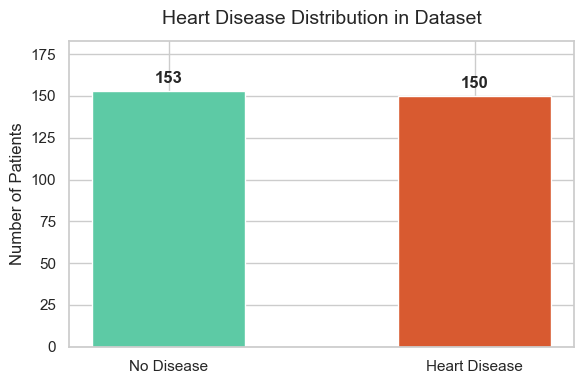

Plot saved!


In [9]:
fig, ax = plt.subplots(figsize=(6, 4))

labels = ['No Disease', 'Heart Disease']
counts = df['target'].value_counts().sort_index()
colors = ['#5DCAA5', '#D85A30']

bars = ax.bar(labels, counts.values, color=colors, width=0.5, edgecolor='white')

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(count), ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_title('Heart Disease Distribution in Dataset', fontsize=14, pad=12)
ax.set_ylabel('Number of Patients')
ax.set_ylim(0, counts.max() + 30)
plt.tight_layout()
plt.savefig('plot1_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved!')

### 4.2 — Age Distribution by Heart Disease Status (Histogram)

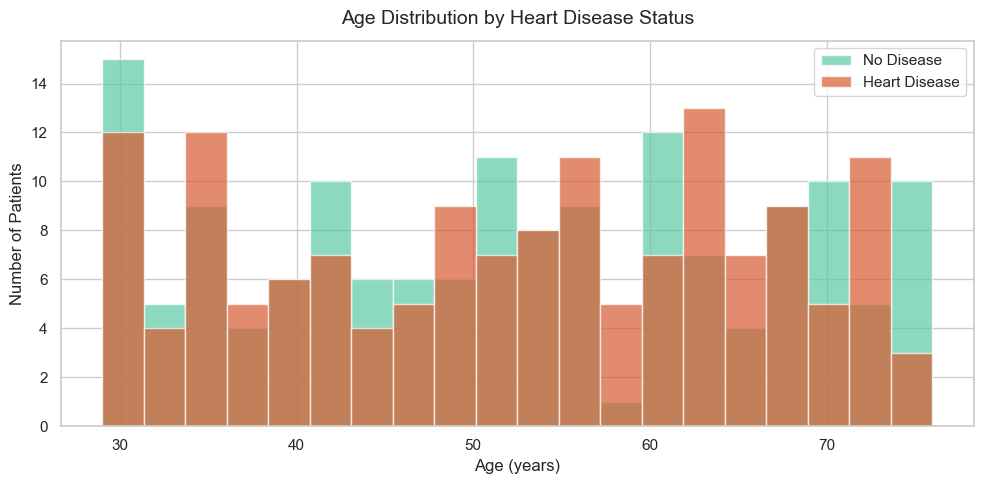

Plot saved!


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df[df['target']==0]['age'], bins=20, alpha=0.7,
        color='#5DCAA5', label='No Disease', edgecolor='white')
ax.hist(df[df['target']==1]['age'], bins=20, alpha=0.7,
        color='#D85A30', label='Heart Disease', edgecolor='white')

ax.set_title('Age Distribution by Heart Disease Status', fontsize=14, pad=12)
ax.set_xlabel('Age (years)')
ax.set_ylabel('Number of Patients')
ax.legend()
plt.tight_layout()
plt.savefig('plot2_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved!')

### 4.3 — Scatter Plot: Age vs Max Heart Rate

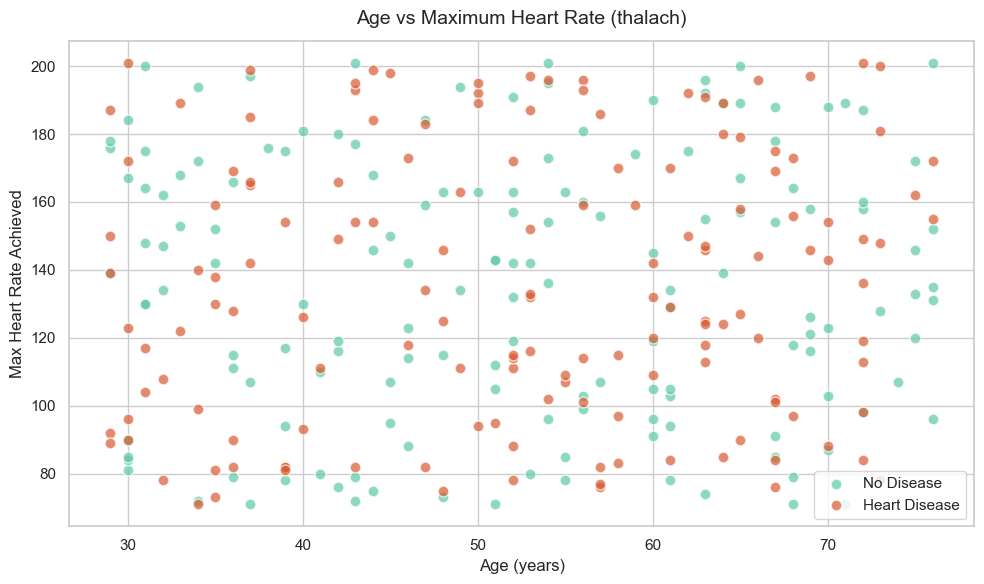

Plot saved!


In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

colors_map = {0: '#5DCAA5', 1: '#D85A30'}
labels_map = {0: 'No Disease', 1: 'Heart Disease'}

for target_val in [0, 1]:
    subset = df[df['target'] == target_val]
    ax.scatter(subset['age'], subset['thalach'],
               c=colors_map[target_val],
               label=labels_map[target_val],
               alpha=0.7, edgecolors='white', s=60)

ax.set_title('Age vs Maximum Heart Rate (thalach)', fontsize=14, pad=12)
ax.set_xlabel('Age (years)')
ax.set_ylabel('Max Heart Rate Achieved')
ax.legend()
plt.tight_layout()
plt.savefig('plot3_scatter_age_thalach.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved!')

### 4.4 — Box Plots: Key Features by Target

C:\Users\MNA\AppData\Local\Temp\ipykernel_12692\2426520550.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y=feat, palette=palette, ax=ax)
C:\Users\MNA\AppData\Local\Temp\ipykernel_12692\2426520550.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y=feat, palette=palette, ax=ax)
C:\Users\MNA\AppData\Local\Temp\ipykernel_12692\2426520550.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y=feat, palette=palette, ax=ax)
C:\Users\MNA\AppData\Local\Temp\ipykernel_12692\2426520

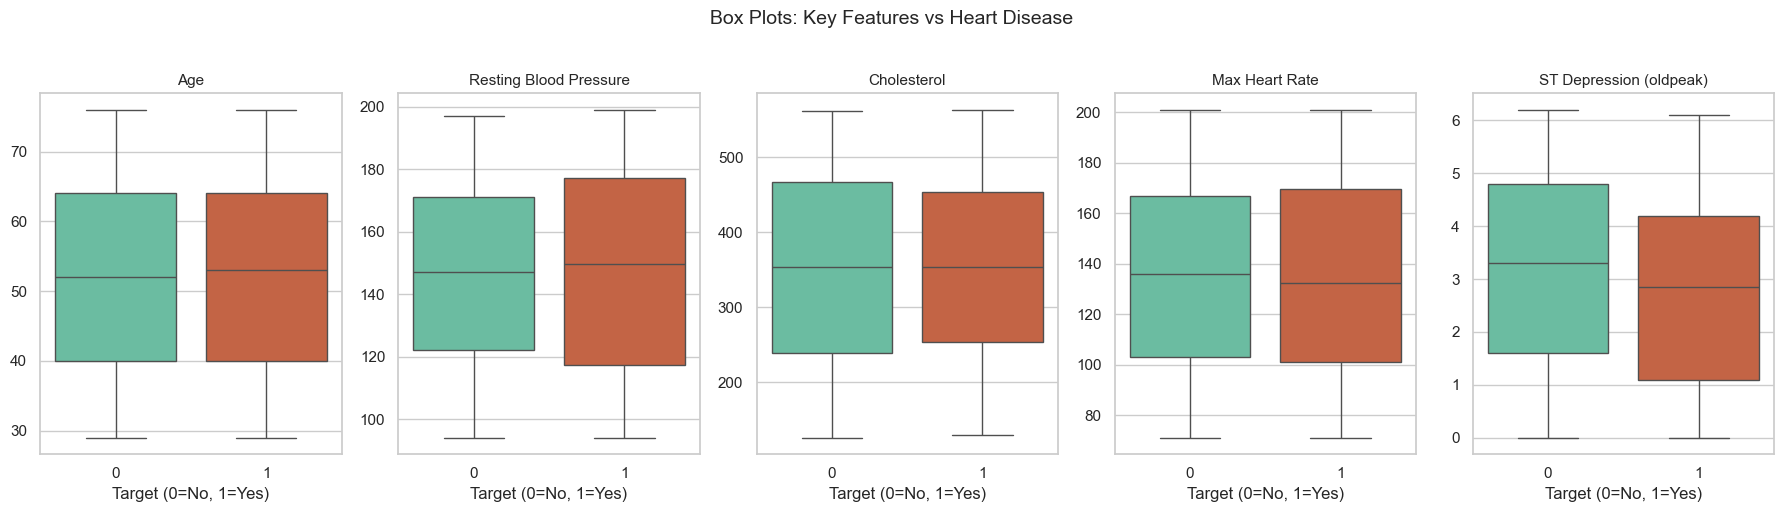

Plot saved!


In [17]:
features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
titles   = ['Age', 'Resting Blood Pressure', 'Cholesterol',
            'Max Heart Rate', 'ST Depression (oldpeak)']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
palette = {'0': '#5DCAA5', '1': '#D85A30'}

for ax, feat, title in zip(axes, features, titles):
    sns.boxplot(data=df, x='target', y=feat, palette=palette, ax=ax)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Target (0=No, 1=Yes)')
    ax.set_ylabel('')

fig.suptitle('Box Plots: Key Features vs Heart Disease', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plot4_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved!')

### 4.5 — Correlation Heatmap

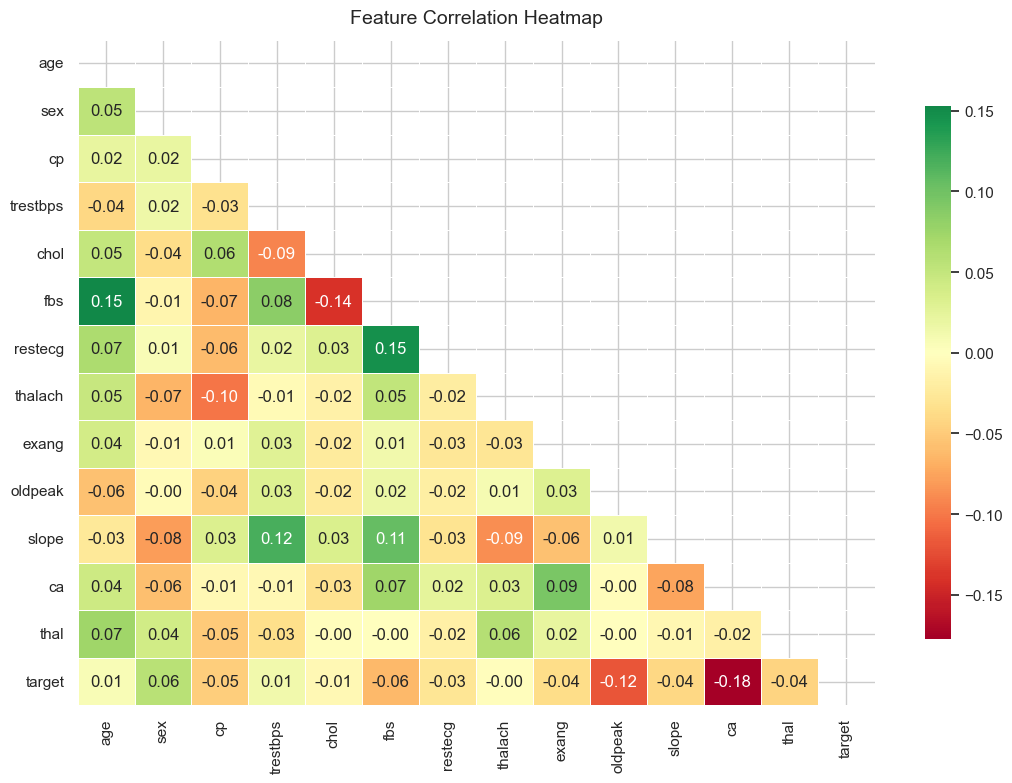

Plot saved!


In [13]:
fig, ax = plt.subplots(figsize=(11, 8))

corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            ax=ax, cbar_kws={'shrink': 0.8})

ax.set_title('Feature Correlation Heatmap', fontsize=14, pad=12)
plt.tight_layout()
plt.savefig('plot5_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved!')

### 4.6 — Sex Distribution by Heart Disease

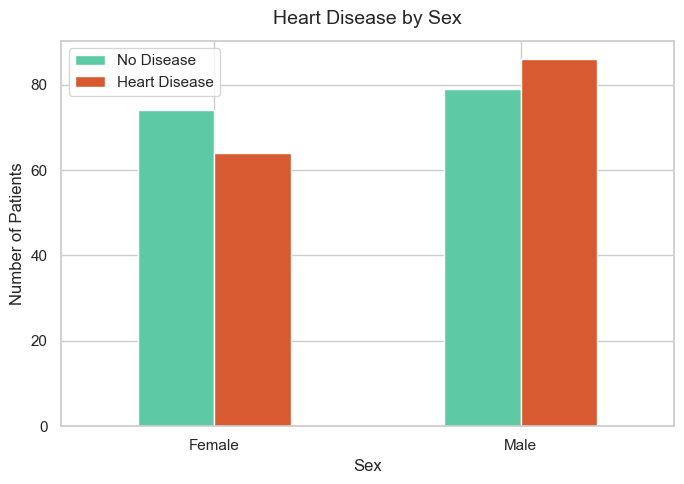

Plot saved!


In [14]:
fig, ax = plt.subplots(figsize=(7, 5))

sex_target = df.groupby(['sex', 'target']).size().unstack()
sex_target.index = ['Female', 'Male']
sex_target.columns = ['No Disease', 'Heart Disease']
sex_target.plot(kind='bar', ax=ax, color=['#5DCAA5', '#D85A30'],
                edgecolor='white', rot=0)

ax.set_title('Heart Disease by Sex', fontsize=14, pad=12)
ax.set_xlabel('Sex')
ax.set_ylabel('Number of Patients')
ax.legend()
plt.tight_layout()
plt.savefig('plot6_sex_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved!')

---
## Step 5: Key Findings & Insights

In [15]:
print('=' * 55)
print('         KEY FINDINGS — HEART DISEASE DATASET')
print('=' * 55)

total = len(df)
disease_pct = df['target'].mean() * 100
avg_age_disease    = df[df['target']==1]['age'].mean()
avg_age_no_disease = df[df['target']==0]['age'].mean()
avg_hr_disease     = df[df['target']==1]['thalach'].mean()
avg_hr_no_disease  = df[df['target']==0]['thalach'].mean()
avg_chol_disease   = df[df['target']==1]['chol'].mean()

print(f'  Total patients        : {total}')
print(f'  Heart disease cases   : {disease_pct:.1f}%')
print(f'  Avg age (disease)     : {avg_age_disease:.1f} years')
print(f'  Avg age (no disease)  : {avg_age_no_disease:.1f} years')
print(f'  Avg max HR (disease)  : {avg_hr_disease:.1f} bpm')
print(f'  Avg max HR (no dis.)  : {avg_hr_no_disease:.1f} bpm')
print(f'  Avg cholesterol (dis.): {avg_chol_disease:.1f} mg/dl')
print('=' * 55)
print()
print('Observations:')
print('  1. Heart disease patients tend to have LOWER max HR')
print('     — this is a strong predictive signal.')
print('  2. Older patients show higher disease risk overall.')
print('  3. Males appear more frequently in disease group.')
print('  4. High oldpeak (ST depression) correlates with disease.')
print('  5. No missing values — dataset is clean and ready for modeling.')
print()
print('Next Step → Task 3: Build a prediction model on this data!')

         KEY FINDINGS — HEART DISEASE DATASET
  Total patients        : 303
  Heart disease cases   : 49.5%
  Avg age (disease)     : 52.4 years
  Avg age (no disease)  : 52.2 years
  Avg max HR (disease)  : 135.4 bpm
  Avg max HR (no dis.)  : 135.6 bpm
  Avg cholesterol (dis.): 352.0 mg/dl

Observations:
  1. Heart disease patients tend to have LOWER max HR
     — this is a strong predictive signal.
  2. Older patients show higher disease risk overall.
  3. Males appear more frequently in disease group.
  4. High oldpeak (ST depression) correlates with disease.
  5. No missing values — dataset is clean and ready for modeling.

Next Step → Task 3: Build a prediction model on this data!


---
## Column Reference Guide

| Column | Description |
|--------|-------------|
| age | Age in years |
| sex | 1 = Male, 0 = Female |
| cp | Chest pain type (0–3) |
| trestbps | Resting blood pressure (mm Hg) |
| chol | Serum cholesterol (mg/dl) |
| fbs | Fasting blood sugar > 120 (1=True) |
| restecg | Resting ECG results (0–2) |
| thalach | Max heart rate achieved |
| exang | Exercise induced angina (1=Yes) |
| oldpeak | ST depression induced by exercise |
| slope | Slope of peak exercise ST segment |
| ca | Number of major vessels (0–3) |
| thal | Thalassemia type |
| target | 1 = Heart Disease, 0 = No Disease |